# 01 -- Sample summary

Loads the final resolved metadata and writes sample summary Table 1.

**Input**
- `table_S1_metadata.tsv` —-> STAGdb metadata for samples included in manuscript

**Output**
- `region_summary.tsv` —-> per-subregion sample counts and centroids

---

## Imports and paths

In [10]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px


In [11]:
# Set APAL_PROJECT_DIR in your environment, or edit the fallback below:
PROJECT_DIR = Path(os.environ.get("APAL_PROJECT_DIR", "/path/to/your/project"))

# input
META_TSV  = PROJECT_DIR / "table_S1_metadata.tsv"

# output
REGION_SUMMARY_TSV = PROJECT_DIR / "table_1_region_summary.tsv"


In [12]:
# these are the column names in the metadata file
ID_COL          = "affymetrix_id"
SPECIES_COL     = "species"
MLG_COL         = "mlg"
REGION_COL      = "region"
SUBREGION_COL   = "region_sub"
REEF_COL        = "reef"
LAT_COL         = "lat_clean"
LON_COL         = "lon_clean"
NURSERY_COL     = "is_nursery"
FACILITY_COL    = "is_facility"
 

## Load metadata

In [13]:
meta = pd.read_csv(META_TSV, sep="\t", low_memory=False)
meta

,affymetrix_id,species,mlg,region,region_sub,region_fix_reason,reef,lat_old,lon_old,lat_clean,...,sexual_recruit,sample_id,user_specimen_id,perc_missing_data,perc_heterozygous,perc_acer,perc_apal,seq_facility,organization,collection_date
0,121170171_(Axiom_AcropSNP)_K05.CEL,A.palmata,HG1491,Bahamas,Bahamas,NaN,AdelaineCay,22.17337,-75.70300,22.17337,...,NaN,A12725,9334,0.17,0.63,0.54,98.80,Eurofins,Penn State,1/13/08
1,121170195_(Axiom_AcropSNP)_O05.CEL,A.palmata,HG1495,Bahamas,Bahamas,NaN,AdelaineCay,22.17337,-75.70300,22.17337,...,NaN,A12749,9345,0.20,0.64,0.67,98.63,Eurofins,Penn State,1/13/08
2,121170183_(Axiom_AcropSNP)_M05.CEL,A.palmata,HG1498,Bahamas,Bahamas,NaN,AdelaineCay,22.17337,-75.70300,22.17337,...,NaN,A12737,9335,0.20,1.03,0.40,98.51,Eurofins,Penn State,1/13/08
3,121166503_(Axiom_AcropSNP)_A05.CEL,A.palmata,HG1544,Bahamas,Bahamas,NaN,BlackBouy,23.80219,-76.14600,23.80219,...,NaN,A12761,1643,0.21,0.56,0.36,99.01,Eurofins,Penn State,2/3/03
4,121166539_(Axiom_AcropSNP)_G05.CEL,A.palmata,HG1550,Bahamas,Bahamas,NaN,BlackBouy,23.80219,-76.14600,23.80219,...,NaN,A12797,1658,0.21,0.34,0.41,99.18,Eurofins,Penn State,2/3/03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,325318639_(Axiom_AcropSNP)_A05.CEL,A.palmata,HG2656,USVI,USVI,NaN,Sugar Beach,17.76005,-64.71513,17.76005,...,NaN,A16830,APAL628,1.29,1.28,0.54,97.48,EuroFins,The Nature Conservancy,10/9/25
4000,325318637_(Axiom_AcropSNP)_M03.CEL,A.palmata,HG2629,USVI,USVI,NaN,Sugar Beach,17.76011,-64.71713,17.76011,...,NaN,A16828,APAL623,0.70,0.70,0.51,98.49,EuroFins,The Nature Conservancy,10/9/25
4001,325318636_(Axiom_AcropSNP)_K03.CEL,A.palmata,HG2629,USVI,USVI,NaN,Sugar Beach,17.76018,-64.71717,17.76018,...,NaN,A16827,APAL622,0.79,0.75,0.52,98.40,EuroFins,The Nature Conservancy,10/9/25
4002,325318638_(Axiom_AcropSNP)_O03.CEL,A.palmata,HG2652,USVI,USVI,NaN,Sugar Beach,17.76022,-64.71649,17.76022,...,NaN,A16829,APAL626,0.70,0.99,0.51,98.18,EuroFins,The Nature Conservancy,10/9/25


In [20]:
region_summary = (
    meta.loc[
        meta[SUBREGION_COL].notna()
    ]
    .groupby(SUBREGION_COL, dropna=False)
    .agg(
        sites=(REEF_COL, "nunique"),
        samples=(ID_COL, "size"),
        genets=(MLG_COL, "nunique"),
        wild_genets=(
            MLG_COL,
            lambda s: s[
                ~meta.loc[s.index, "is_facility"].fillna(False)
            ].nunique()
        ),
        facility=(FACILITY_COL, "sum"),
        latitude=(LAT_COL, "median"),
        longitude=(LON_COL, "median"),
    )
    .reset_index()
    .rename(columns={SUBREGION_COL: "region"})
)

region_summary["region"] = (
    region_summary["region"]
    .astype("string")
    .str.replace(" ", "", regex=False)
)

region_summary["latitude"] = region_summary["latitude"].round(4)
region_summary["longitude"] = region_summary["longitude"].round(4)


_sum_row = {
    "region":      "sum",
    "latitude":    float("nan"),
    "longitude":   float("nan"),
}

for col in region_summary.select_dtypes(include="number").columns:
    if col not in ("latitude", "longitude"):
        _sum_row[col] = region_summary[col].sum()

region_summary = pd.concat(
    [region_summary, pd.DataFrame([_sum_row])],
    ignore_index=True,
)

region_summary = region_summary.rename(columns={
    "wild_genets": "wild_genets",
    "facility":    "facility_samples",
})

# region_summary[["latitude", "longitude"]] = (
#     region_summary[["latitude", "longitude"]]
#     .astype(object)
#     .where(region_summary[["latitude", "longitude"]].notna(), other="")
# )

region_summary

# Table 1

,region,sites,samples,genets,wild_genets,facility_samples,latitude,longitude
0,Bahamas,12,60,51,51,0,24.0631,-76.3738
1,Belize,31,125,78,71,18,16.4657,-88.1990
2,Colombia,18,80,64,64,0,9.8147,-75.8511
3,Colombia_SanAndres,2,5,5,5,0,14.3625,-80.1614
4,Cuba,3,55,44,44,0,23.1732,-82.0993
5,Curacao,19,196,129,129,0,12.0831,-68.8956
6,DominicanRepublic,6,89,79,70,11,18.4012,-68.8466
7,Florida,199,2697,651,227,1813,25.0928,-80.4361
8,Honduras,7,43,35,30,7,16.3000,-86.5200
9,Jamaica,1,16,15,15,0,18.5228,-77.7644


In [21]:
# save tsv
outdir = PROJECT_DIR
outdir.mkdir(exist_ok=True)

tsv_path = outdir / "region_summary.tsv"
region_summary.to_csv(tsv_path, sep="\t", index=False)

# print(f"Saved: {tsv_path.resolve()}")

---
### Plot sample map

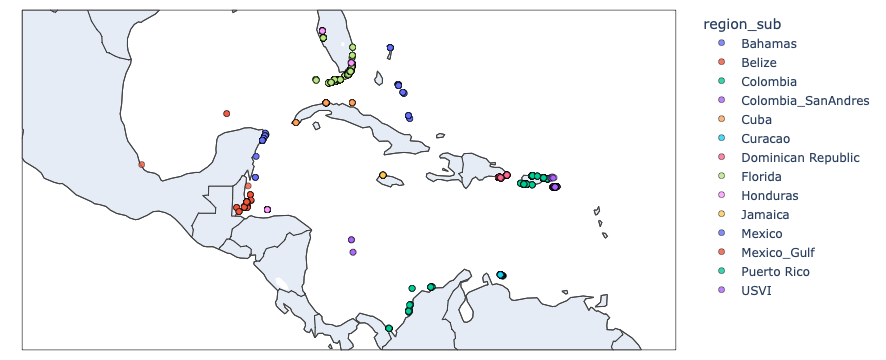

In [22]:
fig = px.scatter_geo(
    meta.dropna(subset=[LAT_COL, LON_COL]),
    lat=LAT_COL, lon=LON_COL,
    color=SUBREGION_COL,
    hover_name=REEF_COL,
    hover_data=[ID_COL, SUBREGION_COL, MLG_COL],
    # title="Apal samples",
    projection="natural earth",
)
fig.update_traces(marker=dict(size=6, opacity=0.8, line=dict(width=0.5, color="black")))
fig.update_geos(showcountries=True, showcoastlines=True, fitbounds="locations",)
fig.update_layout(
    width=800,
    margin=dict(l=10, r=10, t=10, b=10),
)
fig.show()